1. Імпортуємо бібліотеки:


In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("ЛАБОРАТОРНА РОБОТА 5: Багатошаровий перцептрон з нуля")
print("="*60)

ЛАБОРАТОРНА РОБОТА 5: Багатошаровий перцептрон з нуля


2. Готуємо дані. Функція завантажує дані про вино після чого розділяє ознаки та мітки й коригує класи. Дані нормалізуються, поділяються на тренувальну, валідаційну та тестову вибірки, а потім перетворюються у тензори для подальшого використання в нейронній мережі. Повертається підготований набір даних і кількість класів.



In [20]:
# ==================== 1. ПІДГОТОВКА ДАНИХ ====================
def load_and_preprocess_data():
    """Завантажує та підготовлює дані про якість вина"""
    print("\n1. Завантаження та підготовка даних...")

    try:
        data = pd.read_csv('WineQT.csv')
    except:
        # Якщо файл не знайдено, створюємо тестові дані
        print("   Увага: Використовуються тестові дані")
        from sklearn.datasets import make_classification
        X, y = make_classification(n_samples=1143, n_features=11,
                                   n_informative=8, n_redundant=3,
                                   n_classes=6, random_state=42)
        data = pd.DataFrame(X)
        data['quality'] = y

    print(f"   Завантажено {len(data)} зразків")
    print(f"   Кількість ознак: {data.shape[1] - 1}")

    # Відокремлення ознак та міток
    X = data.drop('quality', axis=1).values
    y = data['quality'].values

    # Конвертація у класи 0-5
    if y.min() > 2:
        y = y - y.min()
    num_classes = len(np.unique(y))
    print(f"   Кількість класів: {num_classes}")

    # Нормалізація
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    print("   Нормалізація завершена")

    # Розділення даних
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    print(f"   Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # Конвертація в тензори
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    X_test = torch.FloatTensor(X_test)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    y_test = torch.LongTensor(y_test)

    return X_train, X_val, X_test, y_train, y_val, y_test, num_classes



3. Клас визначає три стандартні функції активації - ReLU, tanh і sigmoid - кожна з яких може повертати як саме значення активації, так і її похідну для використання під час зворотного поширення. Реалізація базується на операціях PyTorch і забезпечує узгоджену структуру виклику для різних активацій.

In [22]:
# ==================== 2. ФУНКЦІЇ АКТИВАЦІЇ ====================
class ActivationFunctions:
    @staticmethod
    def relu(x, derivative=False):
        """ReLU: f(x) = max(0, x)"""
        if derivative:
            return (x > 0).float()
        return torch.maximum(torch.tensor(0.0), x)

    @staticmethod
    def tanh(x, derivative=False):
        """Tanh: f(x) = (e^x - e^(-x)) / (e^x + e^(-x))"""
        if derivative:
            return 1 - torch.tanh(x)**2
        return torch.tanh(x)

    @staticmethod
    def sigmoid(x, derivative=False):
        """Sigmoid: f(x) = 1 / (1 + e^(-x))"""
        if derivative:
            sig = torch.sigmoid(x)
            return sig * (1 - sig)
        return torch.sigmoid(x)


4. Клас реалізує кросентропійну функцію втрат для багатокласової класифікації з можливістю обчислення похідної, оптимізованої для зв’язки softmax + cross-entropy. Також містить власну реалізацію softmax, що нормалізує логіти у ймовірності, забезпечуючи стабільність обчислень.

In [23]:
# ==================== 3. ФУНКЦІЯ ВТРАТ ====================
class LossFunctions:
    @staticmethod
    def categorical_cross_entropy(y_pred, y_true, derivative=False):
        """Categorical Cross-Entropy Loss"""
        batch_size = y_pred.shape[0]

        if derivative:
            # Оптимізована похідна для softmax + cross_entropy
            grad = y_pred.clone()
            grad[range(batch_size), y_true] -= 1
            return grad / batch_size
        else:
            # Обчислення loss
            y_pred_clipped = torch.clamp(y_pred, 1e-10, 1 - 1e-10)
            log_likelihood = -torch.log(y_pred_clipped[range(batch_size), y_true])
            return torch.mean(log_likelihood)

    @staticmethod
    def softmax(x):
        """Softmax activation"""
        exp_x = torch.exp(x - torch.max(x, dim=1, keepdim=True)[0])
        return exp_x / torch.sum(exp_x, dim=1, keepdim=True)


5. Клас реалізує багатошаровий перцептрон із власною ініціалізацією ваг, прямим і зворотним поширенням та оновленням параметрів. Forward-прохід обчислює активації шарів, застосовуючи вибрані функції та softmax на виході, а backward виконує градієнтний спуск через усі шари. Метод train циклічно навчає модель, зберігаючи історію втрат і точності, а predict повертає передбачені класи.


In [24]:
# ==================== 4. ВЛАСНА РЕАЛІЗАЦІЯ MLP ====================
class CustomMLP:
    def __init__(self, layer_sizes, activations, learning_rate=0.01):
        """
        layer_sizes: список розмірів шарів [input, hidden1, hidden2, ..., output]
        activations: список функцій активації для ПРИХОВАНИХ шарів
        """
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.learning_rate = learning_rate
        self.parameters = {}
        self.activation_funcs = ActivationFunctions()

        # Xavier ініціалізація
        for i in range(1, len(layer_sizes)):
            self.parameters[f'W{i}'] = torch.randn(
                layer_sizes[i], layer_sizes[i-1]
            ) * np.sqrt(2.0 / layer_sizes[i-1])
            self.parameters[f'b{i}'] = torch.zeros(layer_sizes[i], 1)

    def forward(self, X, training=True):
        """Forward propagation через мережу"""
        cache = {'A0': X.T}

        for i in range(1, len(self.layer_sizes)):
            A_prev = cache[f'A{i-1}']
            Z = self.parameters[f'W{i}'] @ A_prev + self.parameters[f'b{i}']

            # Застосування активації
            if i == len(self.layer_sizes) - 1:
                # Вихідний шар - softmax
                A = LossFunctions.softmax(Z.T).T
            else:
                # Прихований шар
                activation = self.activations[i-1]
                if activation == 'relu':
                    A = self.activation_funcs.relu(Z)
                elif activation == 'tanh':
                    A = self.activation_funcs.tanh(Z)
                elif activation == 'sigmoid':
                    A = self.activation_funcs.sigmoid(Z)

            cache[f'Z{i}'] = Z
            cache[f'A{i}'] = A

        return cache[f'A{len(self.layer_sizes)-1}'].T, cache

    def backward(self, X, y, cache):
        """Backward propagation та оновлення параметрів"""
        batch_size = X.shape[0]
        gradients = {}

        # Градієнт вихідного шару (softmax + cross-entropy)
        output_layer = len(self.layer_sizes) - 1
        A_output = cache[f'A{output_layer}']

        # Оптимізована похідна: dL/dZ = (y_pred - y_true)
        dZ = A_output.clone()
        dZ[y, range(batch_size)] -= 1
        dZ = dZ / batch_size

        # Backward через шари
        for l in range(output_layer, 0, -1):
            A_prev = cache[f'A{l-1}']

            # Градієнти для W та b
            gradients[f'dW{l}'] = dZ @ A_prev.T
            gradients[f'db{l}'] = torch.sum(dZ, dim=1, keepdim=True)

            if l > 1:
                # Градієнт для попереднього шару
                dA_prev = self.parameters[f'W{l}'].T @ dZ
                Z_prev = cache[f'Z{l-1}']

                # Застосування похідної активації
                activation = self.activations[l-2]
                if activation == 'relu':
                    dZ = dA_prev * self.activation_funcs.relu(Z_prev, derivative=True)
                elif activation == 'tanh':
                    dZ = dA_prev * self.activation_funcs.tanh(Z_prev, derivative=True)
                elif activation == 'sigmoid':
                    dZ = dA_prev * self.activation_funcs.sigmoid(Z_prev, derivative=True)

        # Оновлення параметрів
        for i in range(1, len(self.layer_sizes)):
            self.parameters[f'W{i}'] -= self.learning_rate * gradients[f'dW{i}']
            self.parameters[f'b{i}'] -= self.learning_rate * gradients[f'db{i}']

    def train(self, X_train, y_train, X_val, y_val, epochs=200, verbose=True):
        """Навчання моделі"""
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

        for epoch in range(epochs):
            # Forward pass
            y_pred_train, cache = self.forward(X_train)

            # Обчислення loss
            train_loss = LossFunctions.categorical_cross_entropy(y_pred_train, y_train)

            # Backward pass
            self.backward(X_train, y_train, cache)

            # Валідація
            y_pred_val, _ = self.forward(X_val, training=False)
            val_loss = LossFunctions.categorical_cross_entropy(y_pred_val, y_val)

            # Точність
            train_acc = torch.mean((torch.argmax(y_pred_train, dim=1) == y_train).float())
            val_acc = torch.mean((torch.argmax(y_pred_val, dim=1) == y_val).float())

            history['train_loss'].append(train_loss.item())
            history['val_loss'].append(val_loss.item())
            history['train_acc'].append(train_acc.item())
            history['val_acc'].append(val_acc.item())

            if verbose and (epoch + 1) % 20 == 0:
                print(f'   Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f}, '
                      f'Val Loss: {val_loss:.4f}, Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

        return history

    def predict(self, X):
        """Прогнозування класів"""
        y_pred, _ = self.forward(X, training=False)
        return torch.argmax(y_pred, dim=1)

6. Код створює MLP-модель засобами PyTorch, використовуючи послідовні шари з лінійними перетвореннями, ReLU та Dropout. Функція навчання оптимізує ваги за допомогою Adam і CrossEntropyLoss, веде облік втрат та точності на тренувальних і валідаційних даних та періодично виводить прогрес епох.


In [25]:
# ==================== 5. PYTORCH РЕАЛІЗАЦІЯ ====================
class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(PyTorchMLP, self).__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))  # Додаємо Dropout
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def train_pytorch_model(model, X_train, y_train, X_val, y_val, epochs=200):
    """Навчання PyTorch моделі"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # Навчання
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        # Метрики
        with torch.no_grad():
            train_acc = (torch.argmax(outputs, dim=1) == y_train).float().mean()

            model.eval()
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_acc = (torch.argmax(val_outputs, dim=1) == y_val).float().mean()

        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss.item())
        history['train_acc'].append(train_acc.item())
        history['val_acc'].append(val_acc.item())

        if (epoch + 1) % 20 == 0:
            print(f'   Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}, '
                  f'Val Loss: {val_loss:.4f}, Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

    return history

7. Код будує та зберігає графіки навчання для обох моделей, відображаючи втрати й точність по епохах, а також формує теплові карти матриць помилок для порівняння їх класифікаційної здатності.


In [26]:
# ==================== 6. ВІЗУАЛІЗАЦІЯ ====================
def plot_training_history(history_custom, history_pytorch):
    """Візуалізація процесу навчання"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Custom MLP - Loss
    axes[0, 0].plot(history_custom['train_loss'], label='Train Loss', linewidth=2)
    axes[0, 0].plot(history_custom['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 0].set_title('Custom MLP - Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Custom MLP - Accuracy
    axes[0, 1].plot(history_custom['train_acc'], label='Train Acc', linewidth=2)
    axes[0, 1].plot(history_custom['val_acc'], label='Val Acc', linewidth=2)
    axes[0, 1].set_title('Custom MLP - Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # PyTorch - Loss
    axes[1, 0].plot(history_pytorch['train_loss'], label='Train Loss', linewidth=2)
    axes[1, 0].plot(history_pytorch['val_loss'], label='Val Loss', linewidth=2)
    axes[1, 0].set_title('PyTorch MLP - Loss', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # PyTorch - Accuracy
    axes[1, 1].plot(history_pytorch['train_acc'], label='Train Acc', linewidth=2)
    axes[1, 1].plot(history_pytorch['val_acc'], label='Val Acc', linewidth=2)
    axes[1, 1].set_title('PyTorch MLP - Accuracy', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history_fixed.png', dpi=300, bbox_inches='tight')
    print("\n   Графік збережено: training_history_fixed.png")
    plt.show()


def plot_confusion_matrix(y_true, y_pred_custom, y_pred_pytorch):
    """Матриці помилок для обох моделей"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Custom MLP
    cm_custom = confusion_matrix(y_true, y_pred_custom)
    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Custom MLP - Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    # PyTorch MLP
    cm_pytorch = confusion_matrix(y_true, y_pred_pytorch)
    sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title('PyTorch MLP - Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')

    plt.tight_layout()
    plt.savefig('confusion_matrices_fixed.png', dpi=300, bbox_inches='tight')
    print("   Матриці помилок збережено: confusion_matrices_fixed.png")
    plt.show()

8. Код послідовно запускає повний цикл роботи: завантажує та готує дані, навчає власний MLP і модель на PyTorch, обчислює їхню точність на тесті, порівнює результати, будує графіки навчання та матриці помилок, а наприкінці виводить детальний звіт і підсумовує виконання лабораторної роботи.



1. Завантаження та підготовка даних...
   Завантажено 1143 зразків
   Кількість ознак: 12
   Кількість класів: 6
   ✓ Нормалізація завершена
   Train: (800, 12), Val: (171, 12), Test: (172, 12)

2. Навчання власної реалізації MLP...
   Архітектура: [12, 64, 32, 6]
   Активації: ReLU → ReLU
   Epoch 20/200 - Loss: 1.1971, Val Loss: 1.1179, Acc: 0.4512, Val Acc: 0.5088
   Epoch 40/200 - Loss: 1.1063, Val Loss: 1.0109, Acc: 0.5038, Val Acc: 0.5906
   Epoch 60/200 - Loss: 1.0666, Val Loss: 0.9608, Acc: 0.5362, Val Acc: 0.6082
   Epoch 80/200 - Loss: 1.0430, Val Loss: 0.9316, Acc: 0.5487, Val Acc: 0.6433
   Epoch 100/200 - Loss: 1.0263, Val Loss: 0.9117, Acc: 0.5738, Val Acc: 0.6667
   Epoch 120/200 - Loss: 1.0128, Val Loss: 0.8965, Acc: 0.5900, Val Acc: 0.6667
   Epoch 140/200 - Loss: 1.0013, Val Loss: 0.8840, Acc: 0.5913, Val Acc: 0.6725
   Epoch 160/200 - Loss: 0.9910, Val Loss: 0.8737, Acc: 0.5925, Val Acc: 0.6959
   Epoch 180/200 - Loss: 0.9816, Val Loss: 0.8654, Acc: 0.5900, Val Acc:

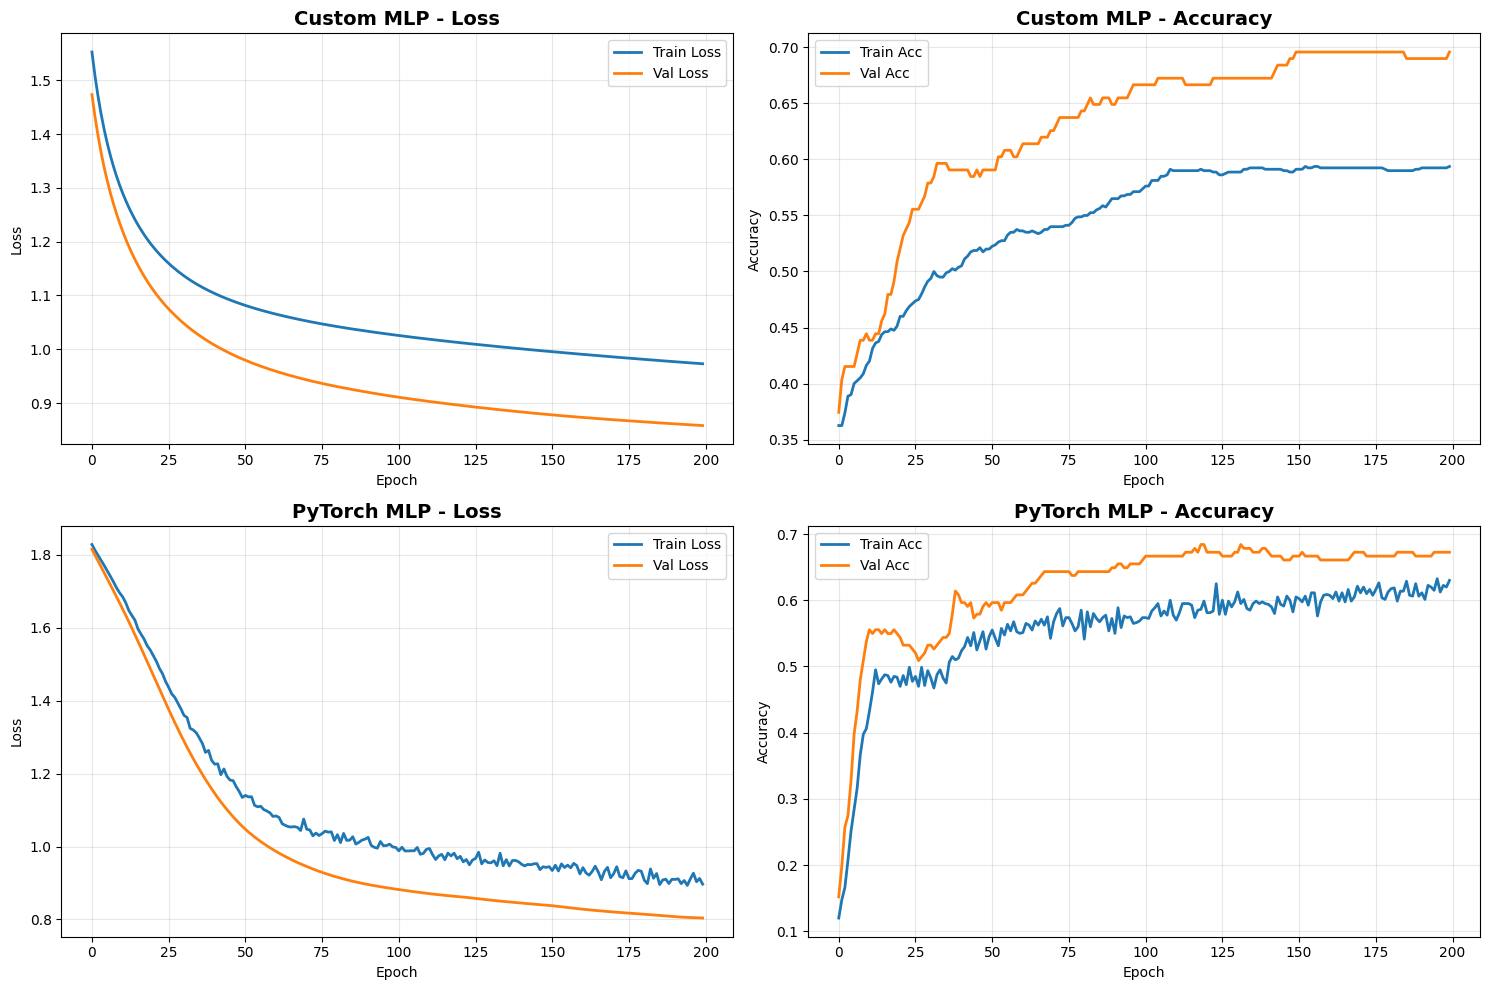

   ✓ Матриці помилок збережено: confusion_matrices_fixed.png


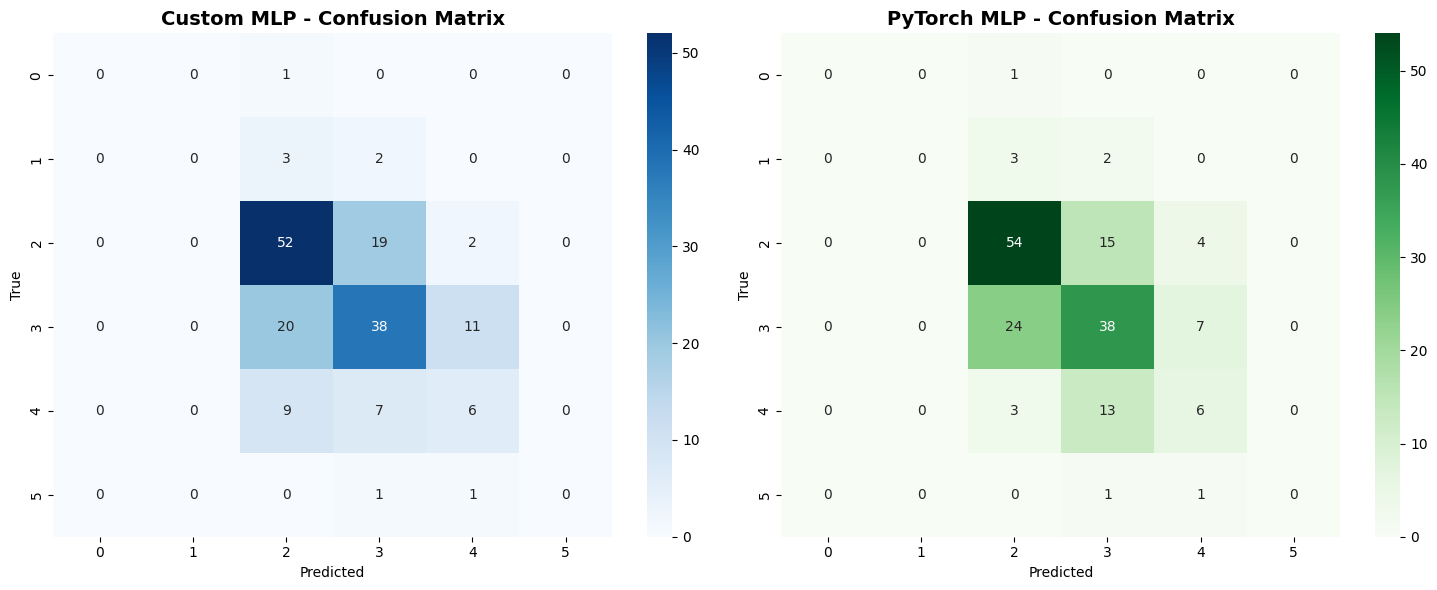


6. Детальна оцінка моделей:

--- Custom MLP ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.61      0.71      0.66        73
           3       0.57      0.55      0.56        69
           4       0.30      0.27      0.29        22
           5       0.00      0.00      0.00         2

    accuracy                           0.56       172
   macro avg       0.25      0.26      0.25       172
weighted avg       0.53      0.56      0.54       172


--- PyTorch MLP ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.64      0.74      0.68        73
           3       0.55      0.55      0.55        69
           4       0.33      0.27      0.30        22
           5       0.00      0.00      0.00         2

    acc

In [28]:
# ==================== ГОЛОВНА ФУНКЦІЯ ====================
def main():
    # 1. Підготовка даних
    X_train, X_val, X_test, y_train, y_val, y_test, num_classes = load_and_preprocess_data()
    input_size = X_train.shape[1]

    # 2. Власна реалізація MLP
    print("\n2. Навчання власної реалізації MLP...")
    print(f"   Архітектура: [{input_size}, 64, 32, {num_classes}]")
    print(f"   Активації: ReLU → ReLU")

    custom_mlp = CustomMLP(
        layer_sizes=[input_size, 64, 32, num_classes],
        activations=['relu', 'relu'],
        learning_rate=0.02  #  Збільшена learning rate
    )

    history_custom = custom_mlp.train(
        X_train, y_train, X_val, y_val,
        epochs=200, verbose=True  # Більше епох
    )

    # 3. PyTorch реалізація
    print("\n3. Навчання PyTorch MLP...")
    pytorch_mlp = PyTorchMLP(input_size, [64, 32], num_classes)
    history_pytorch = train_pytorch_model(
        pytorch_mlp, X_train, y_train, X_val, y_val,
        epochs=200
    )

    # 4. Оцінка на тестовій вибірці
    print("\n4. Оцінка на тестовій вибірці...")

    # Custom MLP
    y_pred_custom = custom_mlp.predict(X_test)
    test_acc_custom = (y_pred_custom == y_test).float().mean()
    print(f"   Custom MLP Test Accuracy: {test_acc_custom:.4f} ({test_acc_custom*100:.2f}%)")

    # PyTorch MLP
    pytorch_mlp.eval()
    with torch.no_grad():
        y_pred_pytorch = torch.argmax(pytorch_mlp(X_test), dim=1)
    test_acc_pytorch = (y_pred_pytorch == y_test).float().mean()
    print(f"   PyTorch MLP Test Accuracy: {test_acc_pytorch:.4f} ({test_acc_pytorch*100:.2f}%)")

    # Різниця
    diff = abs(test_acc_custom.item() - test_acc_pytorch.item()) * 100
    print(f"   Різниця в точності: {diff:.2f}%")

    if diff <= 5:
        print("   Різниця в межах норми (≤5%)")
    else:
        print("   Різниця перевищує 5% - потребує налаштування")

    # 5. Візуалізація
    print("\n5. Створення візуалізацій...")
    plot_training_history(history_custom, history_pytorch)
    plot_confusion_matrix(
        y_test.numpy(),
        y_pred_custom.numpy(),
        y_pred_pytorch.numpy()
    )

    # 6. Детальна оцінка
    print("\n6. Детальна оцінка моделей:")
    print("\n--- Custom MLP ---")
    print(classification_report(y_test.numpy(), y_pred_custom.numpy()))

    print("\n--- PyTorch MLP ---")
    print(classification_report(y_test.numpy(), y_pred_pytorch.numpy()))

    print("\n" + "="*60)
    print(" ЛАБОРАТОРНА РОБОТА ЗАВЕРШЕНА!")
    print("="*60)

    return custom_mlp, pytorch_mlp, history_custom, history_pytorch


if __name__ == "__main__":
    custom_mlp, pytorch_mlp, history_custom, history_pytorch = main()